## Quanto MC Validation

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'pyqflib')))

import qflib as qf
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

print(f'qflib version: {qf.version()}')

qflib version: 1.1.0-debug


### Market Setup

In [2]:
qf.mktClear()

rd = 0.05
rf = 0.03

yc_d = qf.ycCreate('DOM', [1.0, 5.0, 10.0], [rd, rd, rd], 0)
yc_f = qf.ycCreate('FOR', [1.0, 5.0, 10.0], [rf, rf, rf], 0)

spot     = 100.0
strike   = 100.0
timetoexp = 1.0
divyield  = 0.02
assetvol  = 0.20
fxvol     = 0.15
correl    = 0.30

print(f'DOM curve: {yc_d},  r_d={rd}')
print(f'FOR curve: {yc_f},  r_f={rf}')

DOM curve: DOM,  r_d=0.05
FOR curve: FOR,  r_f=0.03


### Analytical Quanto BS Price

The quanto-adjusted dividend yield is $q' = r_d - r_f + q - \rho\sigma_S\sigma_Q$.
We then apply the standard Black-Scholes formula with discount rate $r_d$ and dividend yield $q'$.

In [3]:
q_prime = rd - rf + divyield - correl * assetvol * fxvol
print(f"q' = r_d - r_f + q - rho*sigmaS*sigmaQ = {q_prime:.6f}")

call_bs = qf.euroBS(payofftype=1,  spot=spot, strike=strike, timetoexp=timetoexp,
                    intrate=rd, divyield=q_prime, volatility=assetvol)[0]
put_bs  = qf.euroBS(payofftype=-1, spot=spot, strike=strike, timetoexp=timetoexp,
                    intrate=rd, divyield=q_prime, volatility=assetvol)[0]

print(f'Analytical quanto call: {call_bs:.6f}')
print(f'Analytical quanto put:  {put_bs:.6f}')

q' = r_d - r_f + q - rho*sigmaS*sigmaQ = 0.031000
Analytical quanto call: 8.596437
Analytical quanto put:  6.771823


### MC Pricing vs Analytical

In [4]:
mcparams = {'URNGTYPE': 'MT19937', 'PATHGENTYPE': 'EULER', 'CONTROLVARTYPE': 'ANTITHETIC'}
npaths = 500000

mc_call = qf.qEuroBSMC(payofftype=1,  strike=strike, timetoexp=timetoexp, spot=spot,
                        discountcrv='DOM', divyield=divyield, volatility=assetvol,
                        mcparams=mcparams, npaths=npaths,
                        growthcrv='FOR', fxvol=fxvol, correl=correl)

mc_put  = qf.qEuroBSMC(payofftype=-1, strike=strike, timetoexp=timetoexp, spot=spot,
                        discountcrv='DOM', divyield=divyield, volatility=assetvol,
                        mcparams=mcparams, npaths=npaths,
                        growthcrv='FOR', fxvol=fxvol, correl=correl)

print(f"{'':6}  {'MC Mean':>12}  {'StdErr':>10}  {'Analytical':>12}  {'Error':>10}")
print(f"{'Call':6}  {mc_call['Mean']:12.6f}  {mc_call['StdErr']:10.6f}  {call_bs:12.6f}  {mc_call['Mean']-call_bs:10.6f}")
print(f"{'Put':6}  {mc_put['Mean']:12.6f}  {mc_put['StdErr']:10.6f}  {put_bs:12.6f}  {mc_put['Mean']-put_bs:10.6f}")

             MC Mean      StdErr    Analytical       Error
Call        8.589701    0.018871      8.596437   -0.006736
Put         6.766447    0.013343      6.771823   -0.005376


### Convergence Analysis

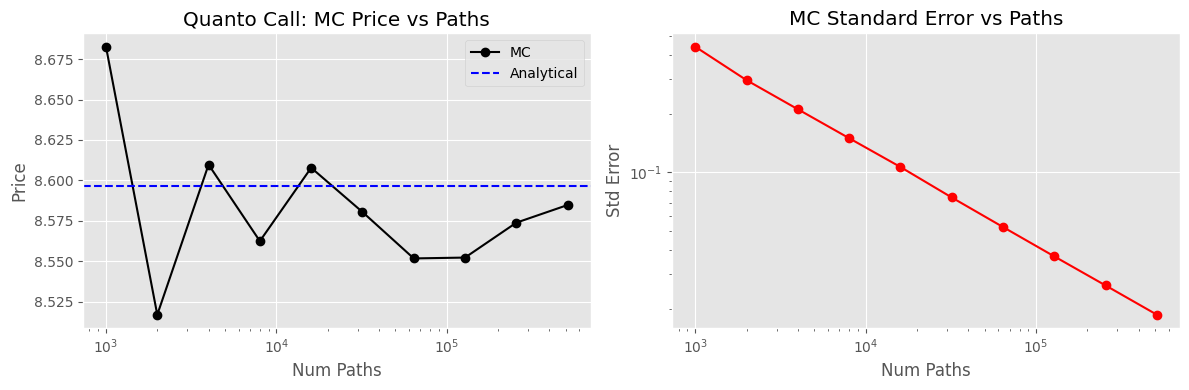

In [5]:
path_counts = [1000 * 2**i for i in range(10)]
mc_prices = []
mc_stderrs = []

for n in path_counts:
    res = qf.qEuroBSMC(payofftype=1, strike=strike, timetoexp=timetoexp, spot=spot,
                        discountcrv='DOM', divyield=divyield, volatility=assetvol,
                        mcparams=mcparams, npaths=n,
                        growthcrv='FOR', fxvol=fxvol, correl=correl)
    mc_prices.append(res['Mean'])
    mc_stderrs.append(res['StdErr'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(path_counts, mc_prices, 'o-', color='black', label='MC')
axes[0].axhline(call_bs, color='blue', linestyle='--', label='Analytical')
axes[0].set_xscale('log')
axes[0].set_title('Quanto Call: MC Price vs Paths')
axes[0].set_xlabel('Num Paths')
axes[0].set_ylabel('Price')
axes[0].legend()

axes[1].plot(path_counts, mc_stderrs, 'o-', color='red')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('MC Standard Error vs Paths')
axes[1].set_xlabel('Num Paths')
axes[1].set_ylabel('Std Error')

plt.tight_layout()
plt.show()

### Limit Check: Strike → 0 Approaches Discounted Quanto Forward

As $K \to 0$ the call price must converge to $e^{-r_d T} F^Q(0,T)$.

In [6]:
qfwd = qf.qFwdPrice(spot=spot, timetoexp=timetoexp, intrate=rf,
                    divyield=divyield, assetvol=assetvol, fxvol=fxvol, correl=correl)
disc_qfwd = qf.discount('DOM', timetoexp) * qfwd
print(f'Quanto forward:            {qfwd:.6f}')
print(f'Discounted quanto forward: {disc_qfwd:.6f}')
print()

small_strikes = [80, 50, 20, 5, 1, 0.1]
print(f"{'Strike':>8}  {'Call':>12}  {'Diff from disc. qFwd':>22}")
for K in small_strikes:
    c = qf.euroBS(payofftype=1, spot=spot, strike=K, timetoexp=timetoexp,
                  intrate=rd, divyield=q_prime, volatility=assetvol)[0]
    print(f'{K:8.2f}  {c:12.6f}  {c - disc_qfwd:22.6f}')

Quanto forward:            101.918165
Discounted quanto forward: 96.947557

  Strike          Call    Diff from disc. qFwd
   80.00     21.788787              -75.158771
   50.00     49.386706              -47.560851
   20.00     77.922969              -19.024588
    5.00     92.191410               -4.756147
    1.00     95.996328               -0.951229
    0.10     96.852434               -0.095123


### Effect of Correlation on Quanto Price

Higher $\rho$ increases the quanto-adjusted drift $(r_f - q + \rho\sigma_S\sigma_Q)$,
which raises $F^Q$ and therefore the call price (and lowers the put price).

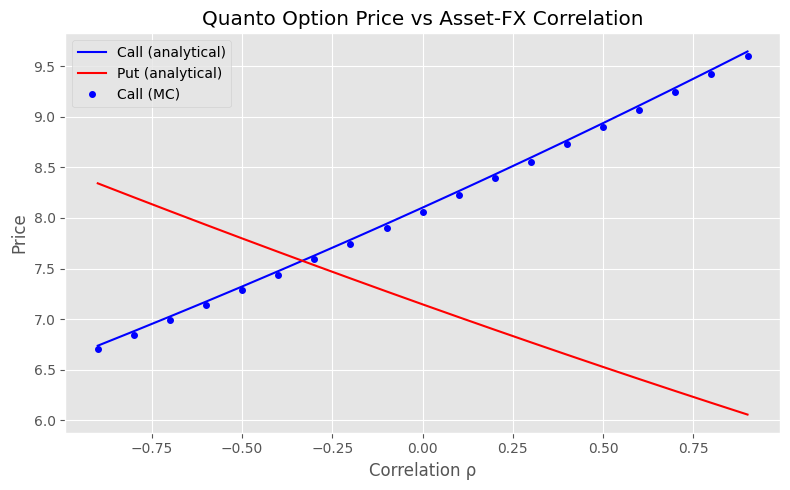

In [7]:
rho_values = np.linspace(-0.9, 0.9, 19)
call_prices = []
put_prices  = []
mc_call_prices = []

for rho in rho_values:
    qp = rd - rf + divyield - rho * assetvol * fxvol
    c = qf.euroBS(payofftype=1,  spot=spot, strike=strike, timetoexp=timetoexp,
                  intrate=rd, divyield=qp, volatility=assetvol)[0]
    p = qf.euroBS(payofftype=-1, spot=spot, strike=strike, timetoexp=timetoexp,
                  intrate=rd, divyield=qp, volatility=assetvol)[0]
    call_prices.append(c)
    put_prices.append(p)

    mc_res = qf.qEuroBSMC(payofftype=1, strike=strike, timetoexp=timetoexp, spot=spot,
                           discountcrv='DOM', divyield=divyield, volatility=assetvol,
                           mcparams=mcparams, npaths=200000,
                           growthcrv='FOR', fxvol=fxvol, correl=rho)
    mc_call_prices.append(mc_res['Mean'])

plt.figure(figsize=(8, 5))
plt.plot(rho_values, call_prices, 'b-',  label='Call (analytical)')
plt.plot(rho_values, put_prices,  'r-',  label='Put (analytical)')
plt.plot(rho_values, mc_call_prices, 'bo', markersize=4, label='Call (MC)')
plt.title('Quanto Option Price vs Asset-FX Correlation')
plt.xlabel('Correlation ρ')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()